In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def read_logfile(filepath, skiprows=0, skipfooter=0):
    # Read the file without assuming the first row as header and avoiding the footer
    df = pd.read_csv(filepath,  delim_whitespace=True, header=None, skiprows=skiprows, skipfooter=skipfooter, engine='python')

    # Assign column names manually if header is missing
    column_names = ['Iteration', 'Time', 'Area', 'Volume', 'ReducedVolume', 'BendingEnergy',
                    'AreaEnergy', 'VolumeEnergy', 'AdhesionEnergy', 'PotentialEnergy', 'TotalEnergy',
                    'KineticEnergy', 'ParticleKineticEnergy', 'EnergyChangeRate', 'ForceResidual']
    df.columns = column_names

    return df

# Paths to the logfiles
# Paths defined similarly as before
file_path_mp_0001 = r"C:\Users\didarula\Desktop\production_run\particle_mass_change\particle_vesicle_mass_ratio_1e-3\logfile.txt"
file_path_mp_00005=r"C:\Users\didarula\Desktop\production_run\particle_mass_change\particle_vesicle_mass_ratio_5e-4\logfile.txt"
file_path_mp_00001 = r"C:\Users\didarula\Desktop\production_run\particle_mass_change\particle_vesicle_mass_ratio_1e-4\logfile.txt"
#file_path_ts_01 = r"C:\Users\didarula\Desktop\production_run\time_step_check\time_step=0.01\logfile.txt"
# Assuming file paths are defined as before and are correct
# Read data from the logfiles
df1 = read_logfile(file_path_mp_0001, skiprows=36, skipfooter=1)
df2 = read_logfile(file_path_mp_00005, skiprows=36, skipfooter=1)
df3 = read_logfile(file_path_mp_00001, skiprows=36, skipfooter=1)

#df4=read_logfile(file_path_ts_01,skiprows=36,skipfooter=1)
#print(df1)

C:\Users\didarula\AppData\Local\Temp\ipykernel_106744\4058621604.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath,  delim_whitespace=True, header=None, skiprows=skiprows, skipfooter=skipfooter, engine='python')
C:\Users\didarula\AppData\Local\Temp\ipykernel_106744\4058621604.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath,  delim_whitespace=True, header=None, skiprows=skiprows, skipfooter=skipfooter, engine='python')
C:\Users\didarula\AppData\Local\Temp\ipykernel_106744\4058621604.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath,  delim_whitespace=True, header=None, skiprows=skiprows, skipfooter=skipfooter, eng

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def extract_rotation_matrices(file_path):
    """Extracts rotation matrices from the .log file."""
    rotation_matrices = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        for i, line in enumerate(lines):
            if "Rotation Matrix:" in line:
                # Extract the next 3 lines as the 3x3 rotation matrix
                R = np.array([
                    list(map(float, lines[i + 1].strip().split())),
                    list(map(float, lines[i + 2].strip().split())),
                    list(map(float, lines[i + 3].strip().split()))
                ])
                rotation_matrices.append(R)
    return np.array(rotation_matrices)

def rotation_matrix_to_axis_angle(R):
    """Convert a 3x3 rotation matrix to axis-angle representation."""
    angle = np.arccos((np.trace(R) - 1) / 2)
    if np.isclose(angle, 0):
        axis = np.array([1, 0, 0])  # Default axis for zero rotation
    else:
        axis = np.array([
            R[2, 1] - R[1, 2],
            R[0, 2] - R[2, 0],
            R[1, 0] - R[0, 1]
        ]) / (2 * np.sin(angle))
    return axis, angle


def calculate_angles(rotation_matrices):
    """Calculate the azimuthal and polar angles from the rotation axes."""
    azimuthal_angles = []
    polar_angles = []
    axis_angles = []
    for R in rotation_matrices:
        axis, angle = rotation_matrix_to_axis_angle(R)
        r = np.linalg.norm(axis)
        if r == 0:
            azimuthal_angles.append(0)
            polar_angles.append(0)
        else:
            v = axis / r
            azimuthal_angle = np.arctan2(v[1], v[0])
            polar_angle = np.arccos(v[2])
            azimuthal_angles.append(azimuthal_angle)
            polar_angles.append(polar_angle)
        axis_angles.append(angle)
    return np.array(azimuthal_angles), np.array(polar_angles), np.array(axis_angles)


In [3]:

# Paths defined similarly as before
file_path_mp_0001= r"C:\Users\didarula\Desktop\production_run\particle_mass_change\particle_vesicle_mass_ratio_1e-3\mp=0.015.log"
file_path_mp_00005 =r"C:\Users\didarula\Desktop\production_run\particle_mass_change\particle_vesicle_mass_ratio_5e-4\mp=0.007.log" 
file_path_mp_00001 = r"C:\Users\didarula\Desktop\production_run\particle_mass_change\particle_vesicle_mass_ratio_1e-4\mp=0.0015.log"
# Assuming file paths are defined as before and are correct

# Extract rotation matrices
rotation_matrices_mp_0001 = extract_rotation_matrices(file_path_mp_0001)
rotation_matrices_mp_00005 = extract_rotation_matrices(file_path_mp_00005)
rotation_matrices_mp_00001 = extract_rotation_matrices(file_path_mp_00001)

# Calculate angles
azimuthal_mp_0001, polar_mp_0001, axis_angle_mp_0001 = calculate_angles(rotation_matrices_mp_0001)
azimuthal_mp_00005, polar_mp_00005, axis_angle_mp_00005 = calculate_angles(rotation_matrices_mp_00005)
azimuthal_mp_00001, polar_mp_00001, axis_angle_mp_00001 = calculate_angles(rotation_matrices_mp_00001)

In [4]:
(len(df2['Time'])==len(azimuthal_mp_00005))

True

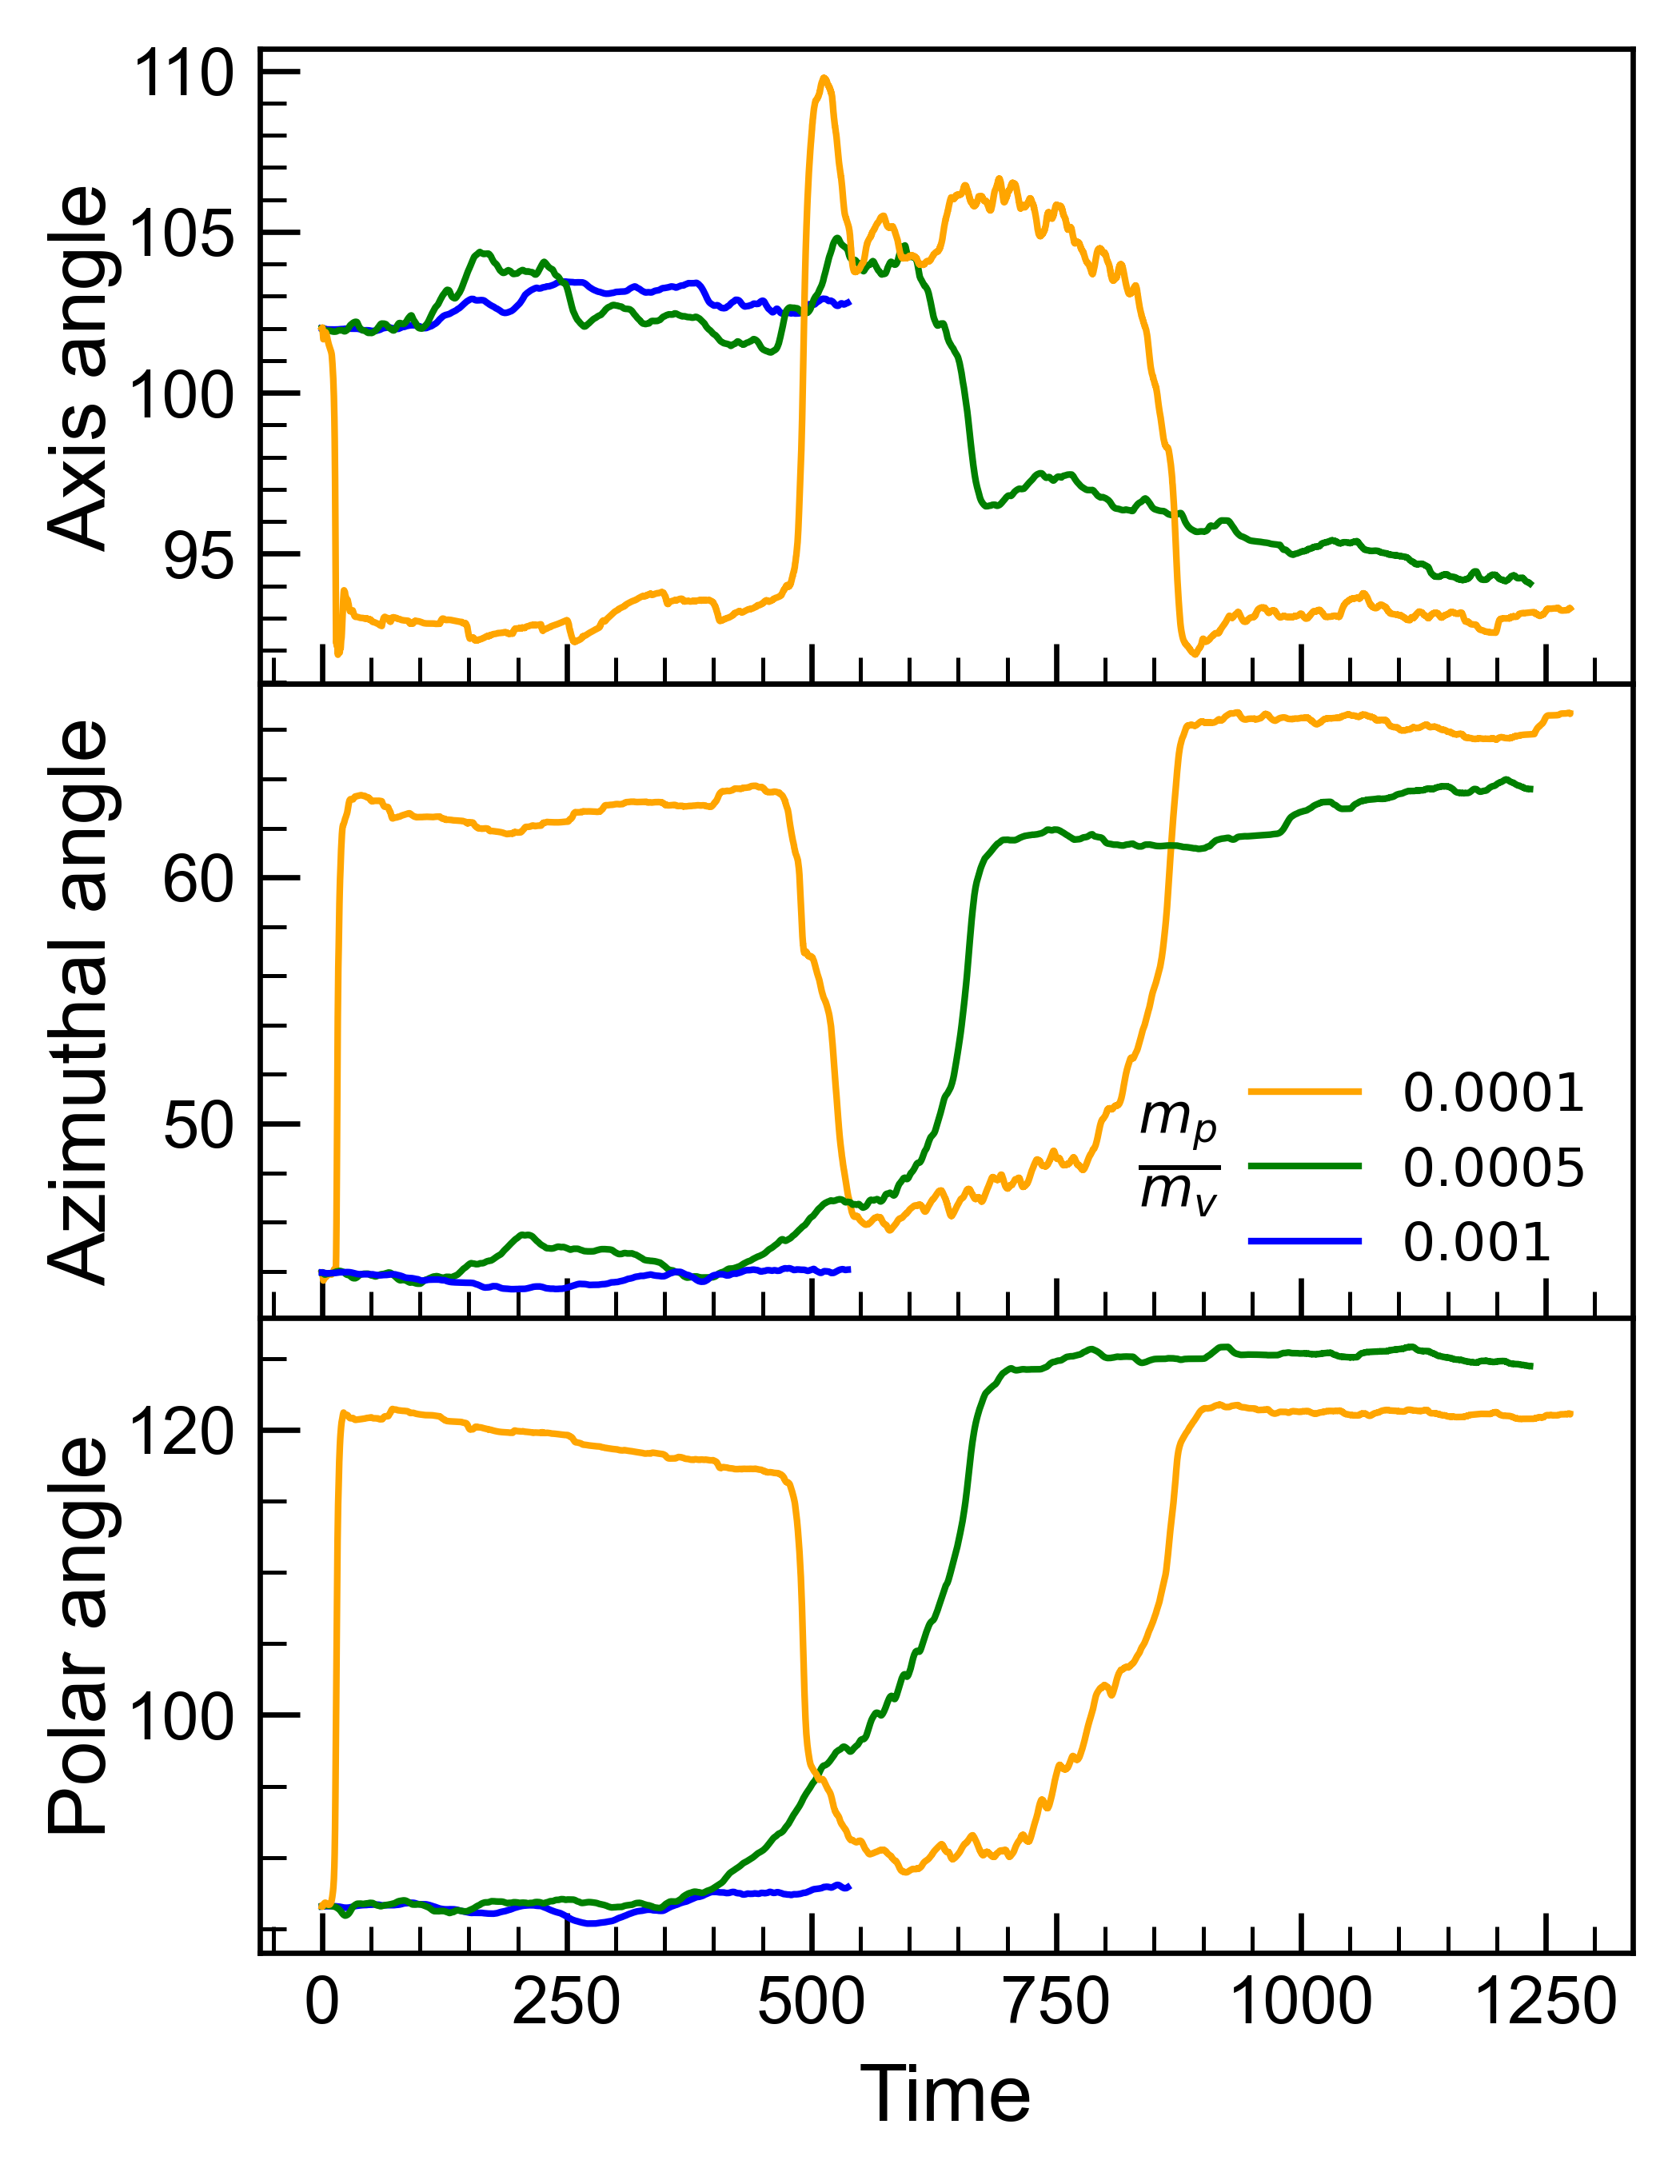

In [20]:
import matplotlib.pyplot as plt

import matplotlib as mpl
import numpy as np
from matplotlib.ticker import AutoMinorLocator

# Constants and style
kb = 0.01
plt.rcParams['font.family'] = 'Arial'
#mpl.rcParams['figure.dpi'] = 600
mpl.rcParams.update({
    #'figure.figsize':       (fig_width_in, fig_height_in),
    'figure.dpi':           600,
    'font.family':          'Arial',
    'font.size':            12,
    'axes.labelsize':       12,
    'xtick.labelsize':      10,
    'ytick.labelsize':      10,
    'legend.fontsize':      10,
    'lines.linewidth':      1,
})

# Create the figure and subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(3.27, 4.36), sharex=True)

# Plotting data for each subplot
ax1.plot(df1['Time'], np.degrees(axis_angle_mp_0001), '-',linewidth=1,color='blue',label='$ m_p/m_v = 0.001$')
ax1.plot(df2['Time'], np.degrees(axis_angle_mp_00005), '-', linewidth=1,color='green',label='$ m_p/m_v = 0.0005$')
ax1.plot(df3['Time'], np.degrees(axis_angle_mp_00001), '-', linewidth=1,color='#FFA500',label='$ m_p/m_v = 0.0001$')
ax1.set_ylabel('Axis angle')
#ax1.legend(loc='upper right', frameon=False, fontsize=12)
ax2.plot(df3['Time'], np.degrees(polar_mp_00001), '-', linewidth=1,color='#FFA500',label='$0.0001$')
ax2.plot(df2['Time'], np.degrees(polar_mp_00005), '-', linewidth=1,color='green',label='$0.0005$')
ax2.plot(df1['Time'], np.degrees(polar_mp_0001), '-' ,linewidth=1,color='blue',label='$0.001$')
#ax2.plot(df2['Time'], np.degrees(polar_mp_00005), '-', linewidth=1,color='green',label='$ m_p/m_v = 0.0005$')
#ax2.plot(df3['Time'], np.degrees(polar_mp_00001), '-', linewidth=1,color='#FFA500',label='$ m_p/m_v = 0.0001$')
ax2.text(
    0.67, 0.25,
    r'$\frac{m_p}{m_v}$',  # note the leading and trailing $
    transform=ax2.transAxes,
    ha='center', va='center',
    fontsize=12,
    bbox=dict(
        boxstyle='round,pad=0.3',
        facecolor='white',
        edgecolor='black',
        alpha=0.0
    )
)

ax2.set_ylabel('Azimuthal angle')
ax2.legend(loc='lower right', frameon=False, fontsize=8)

ax3.plot(df1['Time'], np.degrees(azimuthal_mp_0001), '-' ,linewidth=1,color='blue',label='$ m_p/m_v=0.001 $')
ax3.plot(df2['Time'], np.degrees(azimuthal_mp_00005), '-', linewidth=1,color='green',label='$ m_p/m_v = 0.0005$')
ax3.plot(df3['Time'], np.degrees(azimuthal_mp_00001), '-', linewidth=1,color='#FFA500',label='$ m_p/m_v = 0.0001$')
ax3.set_ylabel('Polar angle')
ax3.set_xlabel('Time')
#ax3.legend(loc='lower right', frameon=False, fontsize=8)
# Adjusting minor and major ticks settings
axes = [ax1, ax2, ax3]
for ax in axes:
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(axis='both', direction='in', which='major', length=6)
    ax.tick_params(axis='both', direction='in', which='minor', length=4)

# Align y-axis labels
label_x = -0.10  # Adjust this value to fit your figure's layout
for ax in axes:
    ax.yaxis.set_label_coords(label_x, 0.5)

# Adjust subplot spacing
plt.subplots_adjust(hspace=0.0)  # Eliminate horizontal space between subplots
plt.tight_layout(pad=0.0)
plt.savefig('mass_effect_check.jpeg', dpi=600,bbox_inches='tight')
plt.show()


In [ ]:


# Paths defined similarly as before
file_path_mp_0001 = r"C:\Users\didarula\Desktop\production_run\particle_mass_change\particle_vesicle_mass_ratio_1e-3\mp=0.015.log"
file_path_mp_001 = r"C:\Users\didarula\Desktop\production_run\particle_mass_change\particle_vesicle_mass_ratio_1e-4\mp=0.0015.log"
file_path_mp_01 = r"C:\Users\didarula\Desktop\production_run\particle_mass_change\particle_vesicle_mass_ratio_5e-4\mp=0.007.log"
# Assuming file paths are defined as before and are correct

# Extract rotation matrices
rotation_matrices_mp_0001 = extract_rotation_matrices(file_path_mp_0001)
rotation_matrices_mp_001 = extract_rotation_matrices(file_path_mp_001)
rotation_matrices_mp_01 = extract_rotation_matrices(file_path_mp_01)

# Calculate angles
azimuthal_mp_0001, polar_mp_0001, axis_angle_mp_0001 = calculate_angles(rotation_matrices_mp_0001)
azimuthal_mp_00005, polar_mp_00005, axis_angle_mp_00005 = calculate_angles(rotation_matrices_mp_001)
azimuthal_mp_00001, polar_mp_00001, axis_angle_mp_0001 = calculate_angles(rotation_matrices_mp_01)

# Time steps
time_0001 = np.arange(len(axis_angle_mp_0001))
time_001 = np.arange(len(axis_angle_mp_001))
time_01 = np.arange(len(axis_angle_mp_01))

# Plotting all angles
fig, axs = plt.subplots(3, 1, figsize=(6, 10), sharex=True)

# Plot Axis Angle
#axs[0].plot(time_0001, np.degrees(axis_angle_mp_0001), label='mp = 0.001 Axis Angle')
axs[0].plot(df2['Time'], np.degrees(axis_angle_mp_001), label='mp = 0.01 ')
axs[0].plot(df3['Time'], np.degrees(axis_angle_mp_01), label='mp = 0.1 ')
axs[0].set_ylabel('Axis Angle (degrees)')
#axs[0].set_title('Axis Angle Over Time')
axs[0].legend()

# Plot Azimuthal Angle
#axs[1].plot(time_0001, np.degrees(azimuthal_mp_0001), label='mp = 0.001 Azimuthal')
axs[1].plot(df2['Time'], np.degrees(azimuthal_mp_001), label='mp = 0.01 ')
axs[1].plot(df3['Time'], np.degrees(azimuthal_mp_01), label='mp = 0.1 ')
axs[1].set_ylabel('Azimuthal Angle (degrees)')
#axs[1].set_title('Azimuthal Angle Over Time')
axs[1].legend()

# Plot Polar Angle
#axs[2].plot(time_0001, np.degrees(polar_mp_0001), label='mp = 0.001 ')
axs[2].plot(df2['Time'], np.degrees(polar_mp_001), label='mp = 0.01 ')
axs[2].plot(df3['Time'], np.degrees(polar_mp_01), label='mp = 0.1 ')
axs[2].set_xlabel('Time Step')
axs[2].set_ylabel('Polar Angle (degrees)')
#axs[2].set_title('Polar Angle Over Time')
axs[2].legend()

plt.tight_layout()
#plt.savefig('axis_polar_azimuthal_angle_vs_time.jpg',dpi=400)
plt.show()
